# Pytorch 

[PyTorch](https://pytorch.org/) is an open-source machine learning framework developed by Facebook's AI Research lab (FAIR). It provides a Python-based scientific computing package that serves as:



> PyTorch is a deep learning library built on Python. It provides GPU acceleration, dynamic computation graphs and an intuitive interface for deep learning researchers and developers. PyTorch follows a "define-by-run" approach meaning that its computational graphs are constructed on the fly allowing for better debugging and model customization.



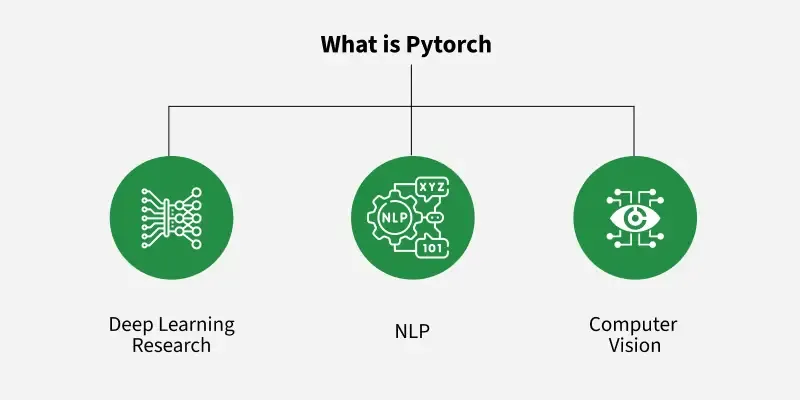


---

### Applications of PyTorch
PyTorch is widely used in various applications, including:
- **Data Manipulation**: Handling and processing multidimensional data structures efficiently.
- **Computer Vision**: Image classification, object detection, and image generation.
- **Natural Language Processing (NLP)**: Text classification, language translation, and sentiment analysis.



**Library Import and Version Verification**

We begin by importing the PyTorch library and verifying the installed version. This step ensures compatibility and helps with debugging potential version-specific issues.

In [2]:
# installing pytorch  
%pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import the PyTorch library
# PyTorch is the primary library for tensor operations and deep learning
import torch

# Display the PyTorch version
# This is crucial for ensuring compatibility with code examples
# Different PyTorch versions may have slight API differences
print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.10.0+cpu



In addition to PyTorch, we will also import other essential libraries that are commonly used in machine learning workflows:
- **NumPy**: A fundamental package for scientific computing with Python, providing support for arrays and mathematical functions.
- **Matplotlib**: A plotting library for creating static, animated, and interactive visualizations in Python.


In [ ]:
import numpy as np 
import matplotlib.pyplot as plt    



## Check for GPU Availability 

PyTorch can leverage the computational power of GPUs to accelerate training and inference. We will check if a GPU is available and set the device accordingly. If a GPU is not available, we will default to using the CPU.     


- `torch.cuda.is_available()` checks if a CUDA-enabled GPU is available on the system.
- `torch.device("cuda")` sets the device to GPU if available, otherwise it defaults to CPU with `torch.device("cpu")`. This allows us to write code that can run on both GPU and CPU without modification.  



In [4]:
# Check if CUDA (GPU support) is available 
print(f"CUDA Available: {torch.cuda.is_available()}")  


# if CUDA is available, set the device to GPU, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}") 
 
# Display the info about GPUs
if torch.cuda.is_available():
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / (1024 ** 3):.2f} GB") 
    print(f"GPU Compute Capability: {torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}") 
else:
    print("No GPU available, using CPU.")


CUDA Available: False
Using device: cpu
No GPU available, using CPU.


# Understanding Tensors 

**Tensors** represent the fundamental data structure in machine learning and deep learning applications. They serve as generalized mathematical objects that can represent:

- **Scalars** (0-dimensional tensors): Single numerical values
- **Vectors** (1-dimensional tensors): Arrays of numbers with directional properties
- **Matrices** (2-dimensional tensors): Rectangular arrays for linear transformations
- **Higher-order tensors** (n-dimensional): Multi-dimensional data structures for complex data


**Tensors constitute the fundamental building blocks of machine learning computations.** In the context of deep learning, tensors serve as the primary data structure for representing:

- **Input data**: Images, text sequences, audio signals, and tabular data
- **Model parameters**: Weights and biases in neural networks
- **Intermediate computations**: Activations and gradients during training
- **Output predictions**: Classification probabilities and regression values






### Creating Tensors 

PyTorch provides various functions to create tensors. Here are some common methods:

1. **From a list or array**: You can create a tensor directly from a Python list or a NumPy array using `torch.tensor()`.
2. **From a NumPy array**: You can create a tensor from a NumPy array using `torch.from_numpy()`.
3. **With specific values**: You can create tensors filled with specific values using functions like `torch.zeros()`, `torch.ones()`, or `torch.full()`.
4. **With random values**: You can create tensors with random values using functions like `torch.rand()`, `torch.randn()`, or `torch.randint()`.   



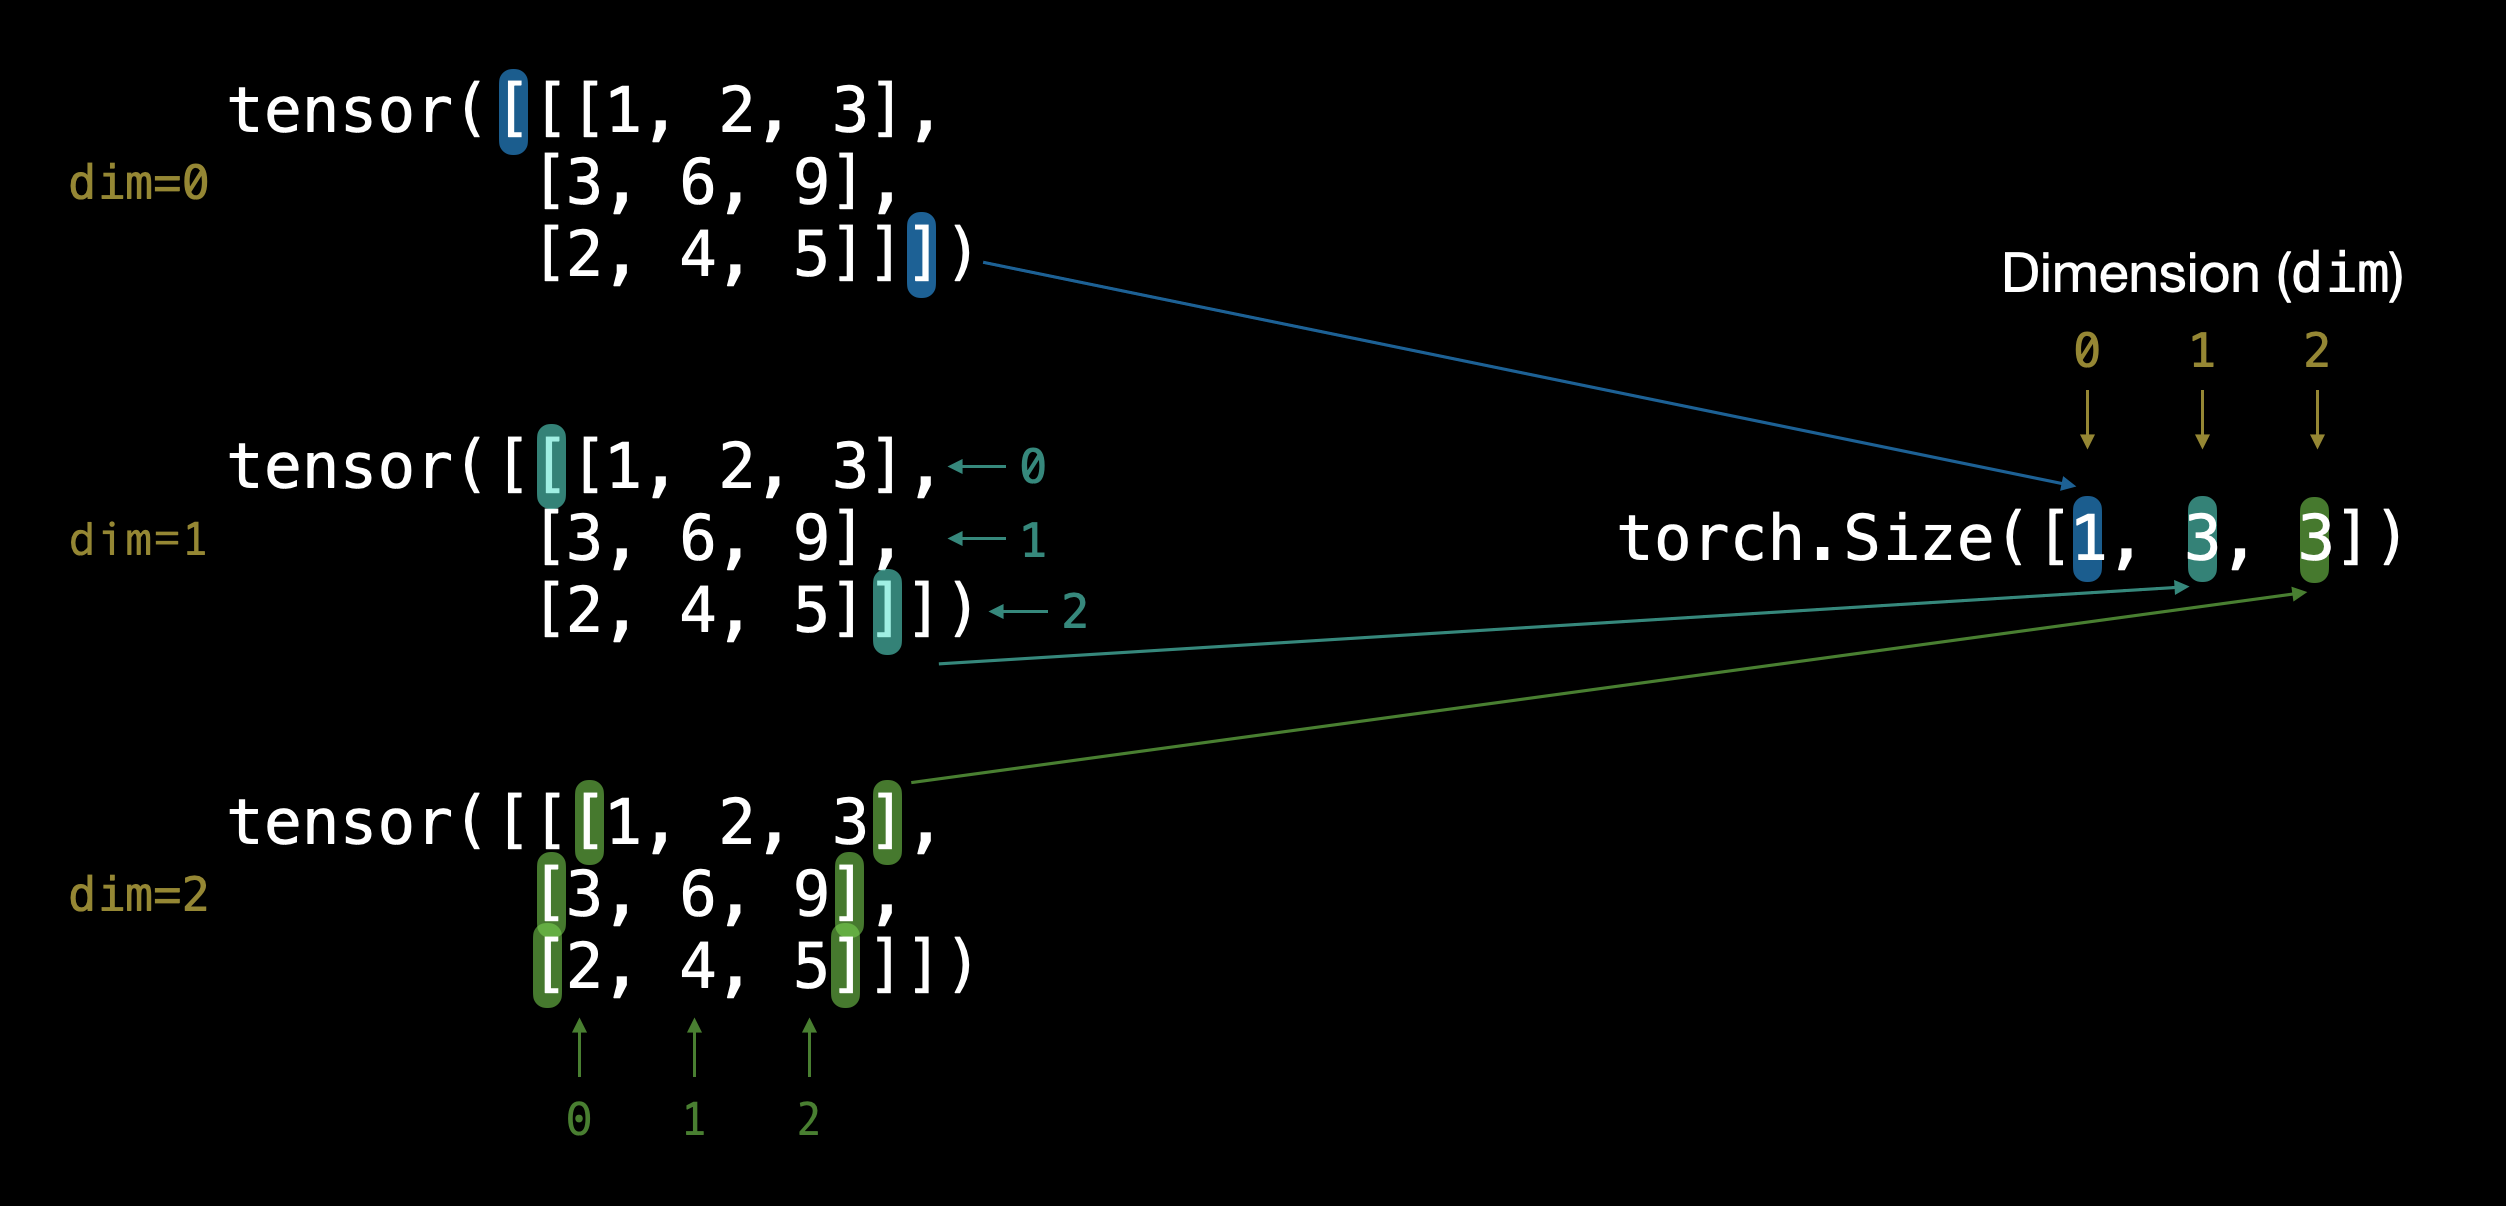




#### Creating tensors from a list


In [5]:
# Create a simple tensors from Python data structures


# Scalar (0D tensor)
scalar_tensor = torch.tensor(7)

# Vector (1D tensor)
vector_tensor = torch.tensor([1, 2, 3, 4, 5])

# Matrix (2D tensor)
# it will be list of lists, where each inner list represents a row of the matrix
matrix_tensor = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])


# Display the created tensors
from IPython.display import display
print(f"Scalar Tensor (0D): {scalar_tensor}")       
print(f"Vector Tensor (1D): {vector_tensor}")       
print(f"Matrix Tensor (2D): {matrix_tensor}")  



# Create a 3D tensor (e.g., a batch of images with 3 color channels)
# it will be a list of matrices, where each matrix represents an image
batch_tensor = torch.tensor([[[255, 0, 0], [0, 255, 0], [0, 0, 255]],
                             [[255, 255, 0], [255, 0, 255], [0, 255, 255]],
                            [[128, 128, 128], [64, 64, 64], [32, 32, 32]]])
print("\n####################################\nBatch Tensor (3D):")      
display(batch_tensor)


     


Scalar Tensor (0D): 7
Vector Tensor (1D): tensor([1, 2, 3, 4, 5])
Matrix Tensor (2D): tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])

####################################
Batch Tensor (3D):


tensor([[[255,   0,   0],
         [  0, 255,   0],
         [  0,   0, 255]],

        [[255, 255,   0],
         [255,   0, 255],
         [  0, 255, 255]],

        [[128, 128, 128],
         [ 64,  64,  64],
         [ 32,  32,  32]]])

#### Creating a tensor from a numpy array

` if i modify the numPy array, the tensor will also change because they share the same memory `


In [6]:
import numpy as np
import torch

# Create a NumPy array
np_array = np.array([[1, 2, 3], [4, 5, 6]])

# Create a tensor from the NumPy array
tensor_from_np = torch.from_numpy(np_array)

print("NumPy Array:")
print(np_array)
print("dtype of NumPy Array:", np_array.dtype)
print("\nTensor from NumPy Array:")
print(tensor_from_np)
print("dtype of Tensor from NumPy Array:", tensor_from_np.dtype)



# if i modify the numPy array, the tensor will also change because they share the same memory
np_array[0, 0] = 99
print("\nAfter modifying the NumPy array:")
print("NumPy Array:")
print(np_array)
print("\nTensor from NumPy Array:")
print(tensor_from_np)       



NumPy Array:
[[1 2 3]
 [4 5 6]]
dtype of NumPy Array: int64

Tensor from NumPy Array:
tensor([[1, 2, 3],
        [4, 5, 6]])
dtype of Tensor from NumPy Array: torch.int64

After modifying the NumPy array:
NumPy Array:
[[99  2  3]
 [ 4  5  6]]

Tensor from NumPy Array:
tensor([[99,  2,  3],
        [ 4,  5,  6]])


#### Creating a tensor from Sequential Values


```python
torch.arange(start=0, end=10, step=2, dtype=torch.float32, device=device, requires_grad=False)
```
- `start`: The starting value of the sequence (inclusive).
- `end`: The ending value of the sequence (exclusive).
- `step`: The increment between each value in the sequence. In this case, it generates even numbers from 0 to 8.
- `dtype`: The data type of the tensor. Here, we specify `torch.float32` to create a tensor of floating-point numbers.
- `device`: The device on which the tensor will be allocated (CPU or GPU).   
- `requires_grad`: A boolean flag that indicates whether the tensor should track gradients for automatic differentiation. In this case, we set it to `False` since we are not performing any operations that require gradient tracking.
  




---
##### .linspace() - Creating a tensor with evenly spaced values between a specified range

```python
torch.linspace(start=0, end=1, steps=5, dtype=torch.float32, device=device, requires_grad=False)
```
- `start`: The starting value of the sequence (inclusive).
- `end`: The ending value of the sequence (exclusive).
- `steps`: The number of evenly spaced values to generate between `start` and `end`.
- `dtype`: The data type of the tensor. Here, we specify `torch.float32` to create a tensor of floating-point numbers.
- `device`: The device on which the tensor will be allocated (CPU or GPU).
- `requires_grad`: A boolean flag that indicates whether the tensor should track gradients for automatic differentiation. In this case, we set it to `False` since we are not performing any operations that require gradient tracking.








In [ ]:
# 





---
##### .logspace() - Creating a tensor with values spaced evenly on a logarithmic scale between a specified range


```python
torch.logspace(start=0, end=1, steps=5, base=10.0, dtype=torch.float32, device=device, requires_grad=False)
```    
This function generates a sequence of numbers that are evenly spaced on a logarithmic scale. The parameters are as follows:
- `start`: The starting exponent value (inclusive).
- `end`: The ending exponent value (exclusive).
- `steps`: The number of evenly spaced values to generate between `start` and `end`.
- `base`: The base of the logarithmic scale.
- `dtype`: The data type of the tensor. Here, we specify `torch.float32` to create a tensor of floating-point numbers.
- `device`: The device on which the tensor will be allocated (CPU or GPU).
- `requires_grad`: A boolean flag that indicates whether the tensor should track gradients for automatic differentiation. In this case, we set it to `False` since we are not performing any operations that require gradient tracking.



In [ ]:
#








```python
torch.eye(n=4, m=4, dtype=torch.float32, device=device, requires_grad=False)
```
This function generates a 2D tensor with ones on the diagonal and zeros elsewhere. The parameters are as follows:
- `n`: The number of rows in the output tensor.
- `m`: The number of columns in the output tensor.
- `dtype`: The data type of the tensor. Here, we specify `torch.float32` to create a tensor of floating-point numbers.
- `device`: The device on which the tensor will be allocated (CPU or GPU).
- `requires_grad`: A boolean flag that indicates whether the tensor should track gradients for automatic differentiation. In this case, we set it to `False` since we are not performing any operations that require gradient tracking.       
  



In [11]:
# identity matrix (2D tensor)
identity_matrix = torch.eye(14)  # creates a 4x4 identity matrix       
print("\nIdentity Matrix (4x4):")
display(identity_matrix)


matrix = torch.eye(4 , 9)  # creates a 4x9 matrix with ones on the diagonal and zeros elsewhere
print("\nIdentity Matrix (4x9):")  
display(matrix)



Identity Matrix (4x4):


tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])


Identity Matrix (4x9):


tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0.]])


```python
torch.full(size=(3, 3), fill_value=7, dtype=torch.float32, device=device, requires_grad=False)
```    
This function generates a tensor filled with a specified value. The parameters are as follows:
- `size`: A tuple that specifies the shape of the output tensor. In this case, we create a 3x3 tensor.
- `fill_value`: The value to fill the tensor with. Here, we specify `7` to create a tensor filled with the value 7.
- `dtype`: The data type of the tensor. Here, we specify `torch.float32` to create a tensor of floating-point numbers.
- `device`: The device on which the tensor will be allocated (CPU or GPU).   
- `requires_grad`: A boolean flag that indicates whether the tensor should track gradients for automatic differentiation. In this case, we set it to `False` since we are not performing any operations that require gradient tracking.




In [8]:
# Create a full tensor of shape (20, 13) filled with the value 7
full_tensor = torch.full((20, 13), 7)
print("Full Tensor:")
print(full_tensor)


Full Tensor:
tensor([[7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7],
        [7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7]])



```python
torch.zeros(size=(2, 2), dtype=torch.float32, device=device, requires_grad=False)
```
This function generates a tensor filled with zeros. The parameters are as follows:
- `size`: A tuple that specifies the shape of the output tensor. In this case, we create a 2x2 tensor.
- `dtype`: The data type of the tensor. Here, we specify `torch.float32` to create a tensor of floating-point numbers.
- `device`: The device on which the tensor will be allocated (CPU or GPU).   
- `requires_grad`: A boolean flag that indicates whether the tensor should track gradients for automatic differentiation. In this case, we set it to `False` since we are not performing any operations that require gradient tracking.       




In [9]:
# Zero tensor of shape (12, 3)
zeros_tensor = torch.zeros((12, 3))
print("Zero Tensor:")
print(zeros_tensor)

Zero Tensor:
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])




```python
torch.ones(size=(2, 3), dtype=torch.float32, device=device, requires_grad=False)
```
This function generates a tensor filled with ones. The parameters are as follows:
- `size`: A tuple that specifies the shape of the output tensor. In this case, we create a 2x3 tensor.
- `dtype`: The data type of the tensor. Here, we specify `torch.float32` to create a tensor of floating-point numbers.
- `device`: The device on which the tensor will be allocated (CPU or GPU).   
- `requires_grad`: A boolean flag that indicates whether the tensor should track gradients for automatic differentiation. In this case, we set it to `False` since we are not performing any operations that require gradient tracking.       



In [10]:
# Create a tensor with ones of shape (15, 9)
ones_tensor = torch.ones((15, 9))   
print("Ones Tensor:")
print(ones_tensor)

Ones Tensor:
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1., 1.]])


---
#### Diagonal Matrix - Creating a tensor with specified values on the diagonal and zeros elsewhere 

```python
torch.diag(torch.tensor([1, 2, 3], dtype=torch.float32, device=device, requires_grad=False))
```   

This function generates a diagonal matrix from a given 1D tensor. The parameters are as follows:
- The input tensor is created using `torch.tensor()`, which contains the values `[1, 2, 3]`. These values will be placed on the diagonal of the output matrix.
- `dtype`: The data type of the tensor. Here, we specify `torch.float32` to create a tensor of floating-point numbers.
- `device`: The device on which the tensor will be allocated (CPU or GPU).
- `requires_grad`: A boolean flag that indicates whether the tensor should track gradients for automatic differentiation. In this case, we set it to `False` since we are not performing any operations that require gradient tracking.

In [14]:

vector = torch.tensor([5, 22, 13, 8, 1])

diagnoal_matrix = torch.diag(vector)  # creates a diagonal matrix from the vector
print("\nDiagonal Matrix from Vector:")   
display(diagnoal_matrix)


# We can also extract the diagonal elements from a matrix using torch.diag() by passing a 2D tensor
matrix_2d = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print("\nOriginal Matrix:")
display(matrix_2d)
diagonal_elements = torch.diag(matrix_2d)  # extracts the diagonal elements from the matrix
print("\nDiagonal Elements from Matrix:") 
display(diagonal_elements)



Diagonal Matrix from Vector:


tensor([[ 5,  0,  0,  0,  0],
        [ 0, 22,  0,  0,  0],
        [ 0,  0, 13,  0,  0],
        [ 0,  0,  0,  8,  0],
        [ 0,  0,  0,  0,  1]])


Original Matrix:


tensor([[1, 2, 3],
        [4, 5, 6],
        [7, 8, 9]])


Diagonal Elements from Matrix:


tensor([1, 5, 9])

#### Random Tensors Generation 

PyTorch provides several functions to generate tensors with random values. These functions are useful for initializing model parameters, creating random data for testing, and performing stochastic operations in machine learning algorithms. Here are some common methods for generating random tensors:
- `torch.rand()`: Generates a tensor with random values uniformly distributed between 0 and 1.
- `torch.randn()`: Generates a tensor with random values drawn from a standard normal distribution (mean=0, std=1).
- `torch.randint()`: Generates a tensor with random integer values between a specified range.     


Random tensors are essential for various applications in machine learning, such as:
- Parameter initialization in neural networks
- Data augmentation for training models : Creating Synthetic training data
- Stochastic Processes : modeling uncertainty and variability in data
- Monte Carlo Simulations : Performing numerical simulations that rely on random sampling

In [16]:
# Create a tensor with random values from uniform distribution [0, 1)
# Random tensors are crucial for neural network weight initialization
# They help break symmetry and enable effective learning

random_tensor = torch.rand(size=(3, 4))  # 3x4 matrix with random values

print(f"Random tensor:\n{random_tensor}")
print(f"Shape: {random_tensor.shape}")
print(f"Data type: {random_tensor.dtype}")

# Statistical analysis of the random tensor:
print(f"\nStatistical properties:")
print(f"Minimum value: {torch.min(random_tensor).item():.6f}")
print(f"Maximum value: {torch.max(random_tensor).item():.6f}")
print(f"Mean value: {torch.mean(random_tensor).item():.6f}")  # Should be ~0.5
print(f"Standard deviation: {torch.std(random_tensor).item():.6f}")  # Should be ~0.289

# Theoretical vs. empirical comparison:
# For uniform distribution U(0,1): theoretical_mean = 0.5, theoretical_std = 1/√12 ≈ 0.289
theoretical_std = 1.0 / (12**0.5)
print(f"Theoretical std for U(0,1): {theoretical_std:.6f}")

# Applications in deep learning:
# 1. Weight initialization: weights = torch.rand(input_size, output_size) * scale
# 2. Dropout simulation: dropout_mask = (torch.rand(size) > dropout_rate).float()
# 3. Data augmentation: noise = torch.rand(data.shape) * noise_level
# 4. Monte Carlo sampling: samples = torch.rand(num_samples, dimensions)

# Note: Each execution will produce different values due to randomness
# This is essential for stochastic training processes in machine learning

random_tensor, random_tensor.dtype

Random tensor:
tensor([[0.2295, 0.7867, 0.1661, 0.8836],
        [0.2449, 0.8467, 0.1951, 0.7321],
        [0.1777, 0.8847, 0.6156, 0.5334]])
Shape: torch.Size([3, 4])
Data type: torch.float32

Statistical properties:
Minimum value: 0.166148
Maximum value: 0.884681
Mean value: 0.524677
Standard deviation: 0.302288
Theoretical std for U(0,1): 0.288675


(tensor([[0.2295, 0.7867, 0.1661, 0.8836],
         [0.2449, 0.8467, 0.1951, 0.7321],
         [0.1777, 0.8847, 0.6156, 0.5334]]),
 torch.float32)

In [ ]:
# Create a random tensor with image-like dimensions
# Common computer vision tensor shape: (height, width, channels)
# This simulates a standard 224x224 RGB image used in many CV models

random_image_size_tensor = torch.rand(size=(224, 224, 3))

print(f"Random image tensor:")
display(random_image_size_tensor)

print(f"Image tensor shape: {random_image_size_tensor.shape}")
print(f"Number of dimensions: {random_image_size_tensor.ndim}")
print(f"Total elements: {random_image_size_tensor.numel():,}")  # Format with commas

# Memory analysis for large tensors:
element_size = random_image_size_tensor.element_size()  # Bytes per element
total_memory = random_image_size_tensor.numel() * element_size
print(f"\nMemory analysis:")
print(f"Bytes per element: {element_size}")
print(f"Total memory usage: {total_memory:,} bytes ({total_memory/1024/1024:.2f} MB)")

# Dimension interpretation for computer vision:
height, width, channels = random_image_size_tensor.shape
print(f"\nImage properties:")
print(f"Height: {height} pixels")
print(f"Width: {width} pixels")
print(f"Channels: {channels} (RGB color channels)")
print(f"Total pixels: {height * width:,}")

# Standard image formats in deep learning:
# - ImageNet standard: 224x224x3 (this example)
# - CIFAR-10: 32x32x3
# - MNIST: 28x28x1 (grayscale)
# - High-resolution: 512x512x3 or larger



# Note: In practice, we often use (C, H, W) format for PyTorch models
# This tensor uses (H, W, C) format, which is common for data loading

random_image_size_tensor.shape, random_image_size_tensor.ndim

Random image tensor:


tensor([[[0.3771, 0.4301, 0.2970],
         [0.0951, 0.2787, 0.6531],
         [0.5883, 0.2543, 0.2431],
         ...,
         [0.1879, 0.8248, 0.4331],
         [0.9810, 0.1776, 0.6143],
         [0.7653, 0.7075, 0.4371]],

        [[0.5375, 0.9399, 0.3071],
         [0.8661, 0.1516, 0.8792],
         [0.2895, 0.5934, 0.3340],
         ...,
         [0.6974, 0.7773, 0.1932],
         [0.8284, 0.7194, 0.7221],
         [0.3187, 0.9057, 0.5396]],

        [[0.9751, 0.2254, 0.7977],
         [0.1896, 0.5393, 0.4872],
         [0.8028, 0.1286, 0.0284],
         ...,
         [0.9567, 0.0537, 0.5209],
         [0.0206, 0.8737, 0.3201],
         [0.7621, 0.4265, 0.6924]],

        ...,

        [[0.0818, 0.1183, 0.0962],
         [0.5545, 0.9076, 0.1516],
         [0.4297, 0.6839, 0.5141],
         ...,
         [0.0369, 0.4613, 0.2621],
         [0.3110, 0.3370, 0.9752],
         [0.3025, 0.6716, 0.2770]],

        [[0.8379, 0.9661, 0.5517],
         [0.8899, 0.1479, 0.6532],
         [0.

Image tensor shape: torch.Size([224, 224, 3])
Number of dimensions: 3
Total elements: 150,528

Memory analysis:
Bytes per element: 4
Total memory usage: 602,112 bytes (0.57 MB)

Image properties:
Height: 224 pixels
Width: 224 pixels
Channels: 3 (RGB color channels)
Total pixels: 50,176


(torch.Size([224, 224, 3]), 3)

## **Tensor datatypes**


The most common type (and generally the default) is `torch.float32` or `torch.float`. But there's also 16-bit floating point (`torch.float16` or `torch.half`) and 64-bit floating point (`torch.float64` or `torch.double`). There's also 8-bit, 16-bit, 32-bit and 64-bit integers.





In [22]:
# Default datatype for tensors is float32
float_32_tensor = torch.tensor([3.0, 6.0, 9.0],
                               dtype=None, # defaults to None, which is torch.float32 or whatever datatype is passed
                               device=None, # defaults to None, which uses the default tensor type
                               requires_grad=False) # if True, operations performed on the tensor are recorded

display(float_32_tensor)
float_32_tensor.shape, float_32_tensor.dtype, float_32_tensor.device

tensor([3., 6., 9.])

(torch.Size([3]), torch.float32, device(type='cpu'))

## Basic Tensor Attributes 

- `tensor.shape`: Returns the shape of the tensor as a tuple, indicating the size of each dimension.
- `tensor.dtype`: Returns the data type of the tensor.
- `tensor.device`: Returns the device on which the tensor is stored.
- `tensor.ndim`: Returns the number of dimensions (or axes) of the tensor.
- `tensor.numel()`: Returns the total number of elements in the tensor, which is the product of the sizes of all dimensions. This is useful for understanding the size of the data contained within the tensor.
- `tensor.element_size()`: Returns the size in bytes of each element in the tensor. This can be useful for calculating the total memory usage of the tensor by multiplying it with `tensor.numel()`.
- `tensor.requires_grad`: Returns a boolean indicating whether the tensor requires gradient computation.
- `tensor.data`: Returns the underlying data of the tensor as a torch.Tensor.



## Basic Tensor Operations 



- `Addition` : `torch.add(a, b)` or `a + b`
- `Subtraction` : `torch.sub(a, b)` or `a - b`
- `Multiplication` : `torch.mul(a, b)` or `a * b`
- `Division` : `torch.div(a, b)` or `a / b`      
- `Exponentiation` : `torch.pow(a, b)` or `a ** b`
- `Matrix Multiplication` : `torch.matmul(a, b)` or `a @ b`
- `Element-wise Multiplication` : `torch.mul(a, b)` or `a * b` 
- `Transposition` : `torch.t(a)` or `a.T` 
  




In [ ]:
tensor_a = torch.tensor([[1.0, 2.0, 3.0], [3, 1, 9], [4, 5, 6]], dtype=torch.float32)

display(tensor_a)


# 
display(tensor_a * tensor_a)

# 
display(torch.multiply(tensor_a, 10))


tensor([[1., 2., 3.],
        [3., 1., 9.],
        [4., 5., 6.]])

tensor([[1., 2., 3.],
        [3., 1., 9.],
        [4., 5., 6.]]) * tensor([[1., 2., 3.],
        [3., 1., 9.],
        [4., 5., 6.]])
Equals: tensor([[ 1.,  4.,  9.],
        [ 9.,  1., 81.],
        [16., 25., 36.]])


tensor([[10., 20., 30.],
        [30., 10., 90.],
        [40., 50., 60.]])

In [32]:
# Demonstrate matrix multiplication using torch.matmul()
# This example shows the mathematical difference between element-wise and matrix multiplication

tensor_a = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float32)  # 1D tensor (vector) 

# Using the previously defined tensor: [1, 2, 3]
print(f"Vector tensor: {tensor_a}")
print(f"Vector shape: {tensor_a.shape}")

# Matrix multiplication for vectors computes the dot product
# Mathematical formula: v · v = Σᵢ vᵢ × vᵢ = v₁² + v₂² + v₃²
matrix_result = torch.matmul(tensor_a, tensor_a)

print(f"\n=== MATRIX MULTIPLICATION (DOT PRODUCT) ===")
print(f"Operation: torch.matmul({tensor_a}, {tensor_a})")
print(f"Mathematical computation: (1×1) + (2×2) + (3×3) = 1 + 4 + 9 = 14")
print(f"Result: {matrix_result}")
print(f"Result shape: {matrix_result.shape}")  # Scalar result (0-dimensional)
print(f"Result type: {type(matrix_result.item())} value = {matrix_result.item()}")

# Interpretation in machine learning contexts:
print(f"\n=== MACHINE LEARNING INTERPRETATIONS ===")
print("1. Similarity measure: Higher dot product indicates more similar vectors")
print("2. Energy/norm calculation: ||v||² = v·v (when v=tensor)")
print(f"3. Vector magnitude: ||v|| = √(v·v) = √{matrix_result.item()} = {torch.sqrt(matrix_result).item():.4f}")
print("4. Neural network computation: Linear layer output = input·weights")

# Computational efficiency note:
print(f"\n=== COMPUTATIONAL NOTES ===")
print("Matrix multiplication is highly optimized in PyTorch:")
print("- Uses BLAS (Basic Linear Algebra Subprograms) libraries")
print("- Automatically leverages multiple CPU cores")
print("- GPU acceleration available via cuBLAS on CUDA devices")
print("- Essential operation for neural network forward/backward passes")

matrix_result

Vector tensor: tensor([1., 2., 3.])
Vector shape: torch.Size([3])

=== MATRIX MULTIPLICATION (DOT PRODUCT) ===
Operation: torch.matmul(tensor([1., 2., 3.]), tensor([1., 2., 3.]))
Mathematical computation: (1×1) + (2×2) + (3×3) = 1 + 4 + 9 = 14
Result: 14.0
Result shape: torch.Size([])
Result type: <class 'float'> value = 14.0

=== MACHINE LEARNING INTERPRETATIONS ===
1. Similarity measure: Higher dot product indicates more similar vectors
2. Energy/norm calculation: ||v||² = v·v (when v=tensor)
3. Vector magnitude: ||v|| = √(v·v) = √14.0 = 3.7417
4. Neural network computation: Linear layer output = input·weights

=== COMPUTATIONAL NOTES ===
Matrix multiplication is highly optimized in PyTorch:
- Uses BLAS (Basic Linear Algebra Subprograms) libraries
- Automatically leverages multiple CPU cores
- GPU acceleration available via cuBLAS on CUDA devices
- Essential operation for neural network forward/backward passes


tensor(14.)



torch.stack() - Concatenating tensors along a specified dimension

```python
torch.stack(tensors, dim=0)
```    
This function concatenates a sequence of tensors along a new dimension specified by `dim`. The parameters are as follows:
- `tensors`: A sequence of tensors to concatenate. All tensors must have the same shape
- `dim`: The dimension along which to concatenate the tensors. For example, if `dim=0`, the tensors will be stacked along the first dimension (creating a new batch dimension). If `dim=1`, they will be stacked along the second dimension, and so on. The resulting tensor will have one more dimension than the input tensors.
- 



In [33]:
import torch
x = torch.arange(1., 8.)
x, x.shape 




(tensor([1., 2., 3., 4., 5., 6., 7.]), torch.Size([7]))

In [34]:
# Add an extra dimension
x_reshaped = x.reshape(1, 7)
x_reshaped, x_reshaped.shape

(tensor([[1., 2., 3., 4., 5., 6., 7.]]), torch.Size([1, 7]))

Remember though, changing the view of a tensor with `torch.view()` really only creates a new view of the *same* tensor.

So changing the view changes the original tensor too.

In [35]:
# Change view (keeps same data as original but changes view)
z = x.view(1, 7)
z, z.shape

(tensor([[1., 2., 3., 4., 5., 6., 7.]]), torch.Size([1, 7]))

In [36]:
# Stack tensors on top of each other
x_stacked = torch.stack([x, x, x, x], dim=0) # try changing dim to dim=1 and see what happens
x_stacked

tensor([[1., 2., 3., 4., 5., 6., 7.],
        [1., 2., 3., 4., 5., 6., 7.],
        [1., 2., 3., 4., 5., 6., 7.],
        [1., 2., 3., 4., 5., 6., 7.]])

In [37]:
print(f"Previous tensor: {x_reshaped}")
print(f"Previous shape: {x_reshaped.shape}")

# Remove extra dimension from x_reshaped
x_squeezed = x_reshaped.squeeze()
print(f"\nNew tensor: {x_squeezed}")
print(f"New shape: {x_squeezed.shape}")

Previous tensor: tensor([[1., 2., 3., 4., 5., 6., 7.]])
Previous shape: torch.Size([1, 7])

New tensor: tensor([1., 2., 3., 4., 5., 6., 7.])
New shape: torch.Size([7])


And to do the reverse of `torch.squeeze()` you can use `torch.unsqueeze()` to add a dimension value of 1 at a specific index.

In [ ]:
print(f"Previous tensor: {x_squeezed}")
print(f"Previous shape: {x_squeezed.shape}")

## Add an extra dimension with unsqueeze
x_unsqueezed = x_squeezed.unsqueeze(dim=0)
print(f"\nNew tensor: {x_unsqueezed}")
print(f"New shape: {x_unsqueezed.shape}")



# GPU Acceleration 

**Graphics Processing Units (GPUs)** have revolutionized deep learning by providing massively parallel computational capabilities. Understanding GPU utilization is essential for practical deep learning applications.

#### **CPU vs GPU Architecture**

**Central Processing Unit (CPU):**
- **Design philosophy**: Optimized for sequential processing and complex control logic
- **Core count**: Typically 4-32 cores with sophisticated caching
- **Memory**: Large, hierarchical cache systems
- **Best for**: Complex branching, single-threaded performance, system management

**Graphics Processing Unit (GPU):**
- **Design philosophy**: Optimized for parallel processing of simple operations
- **Core count**: Thousands of simple cores (e.g., 2,048-10,496 CUDA cores)
- **Memory**: High-bandwidth memory (HBM) with lower latency tolerance
- **Best for**: Matrix operations, element-wise computations, data parallelism

#### **CUDA Ecosystem**

**CUDA (Compute Unified Device Architecture)** enables general-purpose computing on NVIDIA GPUs:
- **Programming model**: Parallel computing platform and API
- **Memory hierarchy**: Global, shared, constant, and texture memory types
- **Execution model**: Kernel launches with thread blocks and grids
- **Library ecosystem**: cuBLAS, cuDNN, cuSPARSE for optimized operations


In [38]:
!nvidia-smi

Fri Mar 13 15:31:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.79                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 2050      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   47C    P0             10W /   70W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [39]:
# Check CUDA availability and system configuration
# This diagnostic is crucial for ensuring optimal performance in deep learning workflows

import torch

# Primary CUDA availability check
cuda_available = torch.cuda.is_available()

print("=== GPU AVAILABILITY DIAGNOSTIC ===")
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    # Detailed GPU information for performance optimization
    print(f"\n=== GPU HARDWARE DETAILS ===")
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    print(f"Current GPU Device: {torch.cuda.current_device()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

    # Memory analysis - critical for batch size optimization
    print(f"\n=== MEMORY CONFIGURATION ===")
    memory_allocated = torch.cuda.memory_allocated(0)
    memory_reserved = torch.cuda.memory_reserved(0)
    total_memory = torch.cuda.get_device_properties(0).total_memory

    print(f"Total GPU Memory: {total_memory / 1024**3:.2f} GB")
    print(f"Currently Allocated: {memory_allocated / 1024**2:.2f} MB")
    print(f"Currently Reserved: {memory_reserved / 1024**2:.2f} MB")
    print(f"Available Memory: {(total_memory - memory_reserved) / 1024**3:.2f} GB")

    # CUDA version compatibility
    print(f"\n=== SOFTWARE VERSIONS ===")
    print(f"PyTorch Version: {torch.__version__}")
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"cuDNN Version: {torch.backends.cudnn.version()}")
    print(f"cuDNN Enabled: {torch.backends.cudnn.enabled}")

else:
    print("\n=== CPU-ONLY CONFIGURATION ===")
    print("GPU acceleration not available. Training will use CPU.")
    print("For large models, consider:")
    print("1. Cloud services (Google Colab, AWS, Azure)")
    print("2. CUDA-compatible GPU installation")
    print("3. Reduced model size and batch size for CPU training")

# Performance implications:
print(f"\n=== PERFORMANCE EXPECTATIONS ===")
if cuda_available:
    print("✓ GPU acceleration available - expect 10-100x speedup for large models")
    print("✓ Large batch sizes supported (limited by GPU memory)")
    print("✓ Suitable for production-scale training")
else:
    print("⚠ CPU-only mode - expect slower training")
    print("⚠ Smaller batch sizes recommended")
    print("⚠ Consider GPU resources for larger experiments")

cuda_available

=== GPU AVAILABILITY DIAGNOSTIC ===
CUDA Available: False

=== CPU-ONLY CONFIGURATION ===
GPU acceleration not available. Training will use CPU.
For large models, consider:
1. Cloud services (Google Colab, AWS, Azure)
2. CUDA-compatible GPU installation
3. Reduced model size and batch size for CPU training

=== PERFORMANCE EXPECTATIONS ===
⚠ CPU-only mode - expect slower training
⚠ Smaller batch sizes recommended
⚠ Consider GPU resources for larger experiments


False